# Setting up the deflectors from lenstool parameter files

Lenstool parameter files and deflection angle maps are used to construct **deflector** instances

In [10]:
import pyLensLib.lenstool as lst

from icecream import ic

############ Interface to observed cluster database
cluster_rgb = ['/Users/massimo/stiva/MACS1206/CLASH/macs1206_RGB.fits',
               '/Users/massimo/stiva/RGBs/macs0416_ff_30mas_RGB.fits',
               '/Users/massimo/stiva/RGBs/2248_ff_RGB.fits',
               '/Users/massimo/stiva/clusters/PSZ1G311/hst_images/j155004m7811-30mas-ir_drz_sci.fits'
               '/Users/massimo/stiva/RGBs/A370_RGB.fits',
               '/Users/massimo/stiva/RGBs/abell2744_RGB.fits',
               '/Users/massimo/stiva/RGBs/macs0717_RGB.fits',
               '/Users/massimo/stiva/RGBs/1149_60mas_ff.fits_RGB.fits',
               '/Users/massimo/stiva/RGBs/macs0329_RGB.fits',
               '/Users/massimo/stiva/RGBs/macs1931_RGB.fits',
               '/Users/massimo/stiva/RGBs/macs2129_RGB.fits',
               '/Users/massimo/stiva/RGBs/rxj2129_RGB.fits']

# cluster nickname (necessari per costruire i nomi dei file da leggere)
cluster = ['S1063','M0416','M1206pl','PSZ1G311_200',
           'A370','A2744','M0717','M1149',
           'M0329','M1931','M2129','R2129']

# posizione delle mappe degli angoli di deflessione
path_to_angles = ['/Users/massimo/stiva/pietro_models/',
                  '/Users/massimo/stiva/pietro_models/',
                  '/Users/massimo/stiva/pietro_models/',
                  '/Users/massimo/stiva/clusters/PSZ1G311/delens/',
                  '/Volumes/GoogleDrive/My Drive/Old_Projects/FF/lens_models/from_params/',
                  '/Users/massimo/stiva/pietro_models/',
                  '/Volumes/GoogleDrive/My Drive/Old_Projects/FF/lens_models/from_params/',
                  '/Volumes/GoogleDrive/My Drive/Old_Projects/FF/lens_models/from_params/',
                  '/Users/massimo/stiva/gabriel_models/best_fit/',
                  '/Users/massimo/stiva/gabriel_models/best_fit/',
                  '/Users/massimo/stiva/gabriel_models/best_fit/',
                  '/Users/massimo/stiva/gabriel_models/best_fit/']


# redshift delle lenti
zl_ = [0.439,0.396,0.348,0.4436,0.375,0.308,0.545,0.543,0.45,0.352,0.587,0.234]

icl = 1 #2
zs = 7 #1.0
print (('Working with cluster %s') % (cluster[icl]))
print ('creating deflector...')
df = lst.create_deflector(parfile = path_to_angles[icl] + cluster[icl] + '.par',
                          filex = path_to_angles[icl] + cluster[icl] + '_angx.fits',
                          filey = path_to_angles[icl] + cluster[icl] + '_angy.fits',
                          zl= zl_[icl], zs = zs, zsnorm = 1.0, resc_fact = 1.0)

lims = lst.getFoV(path_to_angles[icl] + cluster[icl] + '.par')
fov = lims[1]-lims[0]

print (("FOV= %4.1f x %4.1f") % (fov,fov))

Working with cluster M0416
creating deflector...
FOV= 200.0 x 200.0


# Magnification on the source plane

Compute maps of the magnification on the source plane. Then compute the area on the source plane above a given magnification limit and plot the result.

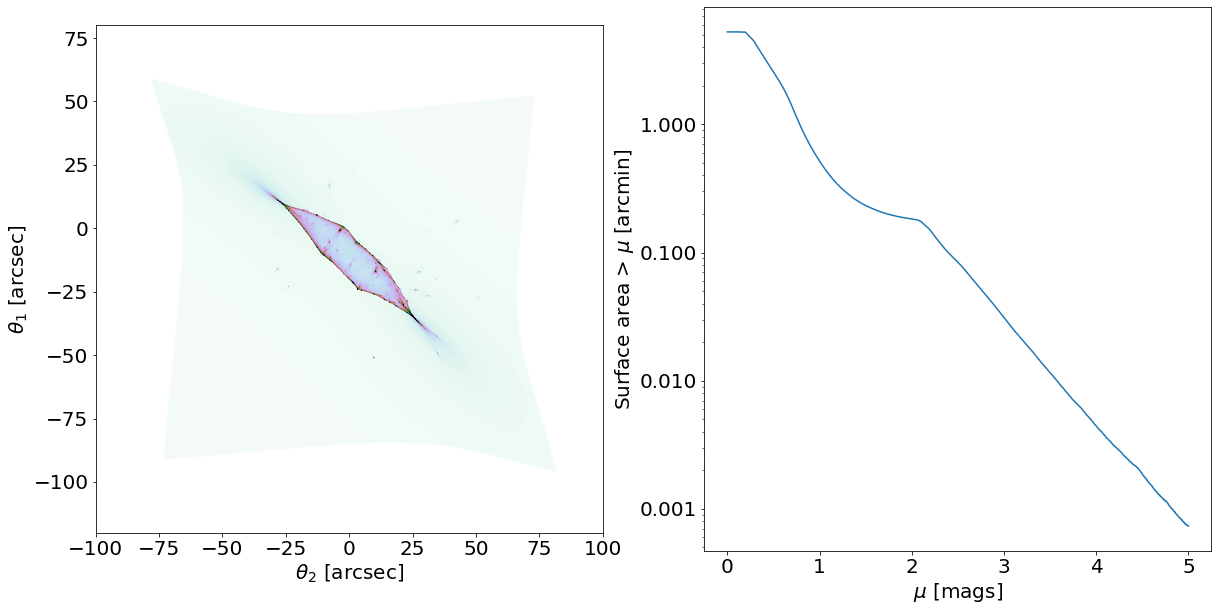

In [11]:
import pymupds
df.change_redshift(zs)
detA = (1.0 - df.ka) ** 2 - (df.g1 ** 2 + df.g2 ** 2)
y1 = df.theta1 - df.a1 + 2 * df.pixel_scale
y2 = df.theta2 - df.a2 + 2 * df.pixel_scale
mus = pymupds.mupds_triangle(y1 - df.theta1.min(), y2 - df.theta2.min(), df.pixel_scale, detA, nray=df.nray1)

import matplotlib.pyplot as plt
import numpy as np
fig,ax = plt.subplots(1,2,figsize=(20,10))
ax[0].imshow(mus,origin='lower',vmax=50,cmap='cubehelix_r',extent=lims)
ax[0].xaxis.set_tick_params(labelsize=20)
ax[0].yaxis.set_tick_params(labelsize=20)
ax[0].set_ylabel(r'$\theta_1$ [arcsec]',fontsize=20)
ax[0].set_xlabel(r"$\theta_2$ [arcsec]",fontsize=20)

mu_lim = np.linspace(1.0,100.0,1000)
asrc = []
for mu_ in mu_lim:
    masked_mus = mus > mu_
    as_ = np.sum(masked_mus)*df.pixel_scale**2/3600.0
    asrc.append(as_)

mu_mag=2.5*np.log10(mu_lim)

ax[1].plot(mu_mag,asrc,'-')
ax[1].set_yscale('log')
ax[1].yaxis.set_major_formatter(plt.FormatStrFormatter('%.3f'))
ax[1].set_ylabel(r'Surface area > $\mu$ [arcmin]',fontsize=20)
ax[1].set_xlabel(r"$\mu$ [mags]",fontsize=20)
ax[1].xaxis.set_tick_params(labelsize=20)
ax[1].yaxis.set_tick_params(labelsize=20)


# Volume (not accounting for completeness or magnification)

7.908636629357858
-11.184795425609067 1.5732388146850198


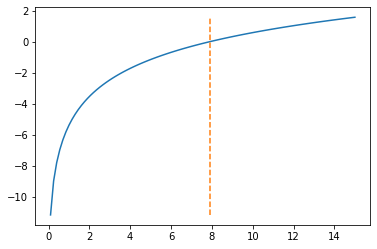

In [12]:
# for a given absolute magnitude, compute the apparent magnitude as a function of
import astropy.units as u
import astropy.cosmology as cosmo

def apparent_magnitude(M, redshift, cosmo):
    d_L = cosmo.luminosity_distance(redshift)
    return M + 5 * np.log10(d_L.to(u.pc).value / 10)

# Example usage
cosmo = cosmo.FlatLambdaCDM(H0=70, Om0=0.3)
M = -19.5

m_lim = 30

redshifts = np.linspace(0.1, 15, 100)
apparent_mags = apparent_magnitude(M, redshifts, cosmo)-m_lim

plt.plot(redshifts, apparent_mags,'-')

import scipy.interpolate as interpolate
import scipy.optimize as optimize

interp_func = interpolate.interp1d(redshifts,apparent_mags)
root = optimize.root_scalar(interp_func,bracket=[0.1,15])
z_max = root.root
print (z_max)

plt.plot([z_max,z_max],[np.min(apparent_mags),np.max(apparent_mags)],'--')
print (np.min(apparent_mags),np.max(apparent_mags))

In [13]:
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM
import numpy as np

def effective_survey_volume(magnitude, z_min, z_max, limiting_magnitude, cosmo):
    """
    Calculate the effective survey volume probed by a given absolute magnitude.

    Parameters:
    - magnitude (float): The absolute magnitude of the source.
    - z_min (float): The minimum redshift of the survey.
    - z_max (float): The maximum redshift of the survey.
    - limiting_magnitude (float): The limiting magnitude of the survey.
    - cosmo

    Returns:
    - float: The effective survey volume probed by the given absolute magnitude.
    """
    redshifts = np.linspace(z_min, z_max, 1000)
    dV_c = np.array([cosmo.differential_comoving_volume(z).value for z in redshifts])
    V_eff = np.trapz(dV_c, redshifts)

    return V_eff




M_abs = -23.0
z_min = 0.1
limiting_magnitude = 30.0
V_eff = effective_survey_volume(M_abs, z_min, z_max, limiting_magnitude, df.co)

print (V_eff/1e9)

236.28142194241218


# Masked maps

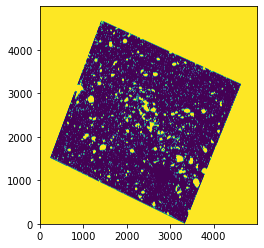

In [14]:
import astropy.io.fits as pyfits
hdul=pyfits.open(path_to_angles[icl]+'mask_final_M0416.fits')
mask = hdul[0].data

plt.imshow(mask,origin='lower')